In [1]:
saved_seds = []

In [32]:
import sys
sys.path.append('/home/mikel/GitHub/iip-emulator')

from tardis.io.configuration.config_reader import Configuration
from tardis.simulation import Simulation
from tardis.io.atom_data.base import AtomData
from param_space.make_csvy import make_csvy
import astropy.units as u
import os

os.environ["OMP_NUM_THREADS"] = "4"
os.environ["MKL_NUM_THREADS"] = "4"
os.environ["NUMEXPR_NUM_THREADS"] = "4"

main_dir = os.path.dirname('/home/mikel/GitHub/iip-emulator/utilities/run_tardis/')
v_start = 5879.888876 * u.km/u.s

# Run simulation
make_csvy(
    v_start,
    v_stop = v_start * 3,
    shells = 10,
    csvy_path=os.path.join(main_dir, 'model.csvy')
)
atomic = AtomData.from_hdf(os.path.join(main_dir, 'atom_data.h5'))
config = Configuration.from_yaml(os.path.join(main_dir, 'config.yml'))

sim = Simulation.from_config(
    config,
    atom_data = atomic,
    log_level='CRITICAL'
)
sim.run_convergence()
sim.run_final()

Zeta_data missing - replaced with 1s. Missing ions: [(26, 27), (27, 28), (28, 29)]
Zeta_data missing - replaced with 1s. Missing ions: [(26, 27), (27, 28), (28, 29)]


TqdmHBox(children=(HTML(value='Iterations:', layout=Layout(width='6%')), FloatProgress(value=0.0, layout=Layou…

TqdmHBox(children=(HTML(value='Packets:\u2007\u2007\u2007', layout=Layout(width='6%')), FloatProgress(value=0.…

In [33]:
print(sim.plasma.plasma_properties_dict.keys())
print(sim.plasma.dilute_planckian_radiation_field.temperature_kelvin)

dict_keys(['DilutePlanckianRadField', 'NumberDensity', 'TimeExplosion', 'AtomicData', 'JBlues', 'LinkTRadTElectron', 'HeliumTreatment', 'ContinuumInteractionSpecies', 'NLTEIonizationSpecies', 'NLTEExcitationSpecies', 'TRadiative', 'DilutionFactor', 'BetaRadiation', 'Levels', 'Lines', 'PartitionFunction', 'GElectron', 'IonizationData', 'LinesLowerLevelIndex', 'LinesUpperLevelIndex', 'TauSobolev', 'StimulatedEmissionFactor', 'SelectedAtoms', 'ElectronTemperature', 'LevelBoltzmannFactorDiluteLTE', 'PhiSahaNebular', 'ZetaData', 'BetaElectron', 'RadiationFieldCorrection', 'LevelBoltzmannFactorNoNLTE', 'BetaSobolev', 'TransitionProbabilities', 'MacroAtomData', 'LevelNumberDensity', 'IonNumberDensity'])
[16938.25498565 16611.96432667 16284.80429226 16052.39155778
 15823.42646392 15155.86858558 14138.76841013 12692.15527176
 11868.80036977 11436.00660926]


In [34]:
y_mod = sim.spectrum_solver.spectrum_virtual_packets.luminosity_density_lambda.value
saved_seds.append(y_mod)

scale guess: 8.070546244377218e+52
scale: 6.151876300423723e+52
distance: 22.675053472860654 Mpc


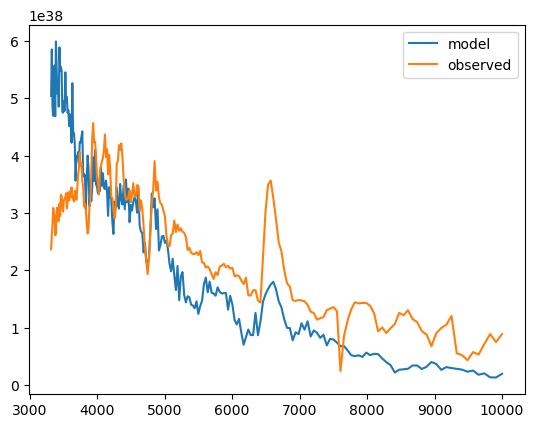

scale guess: 8.410027337211414e+52
scale: 6.085963629175273e+52
distance: 22.5532533775166 Mpc


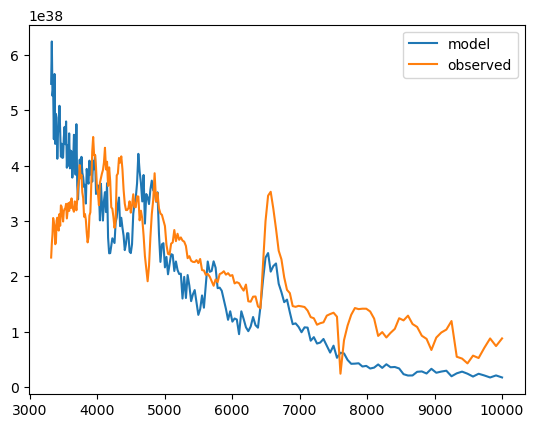

In [35]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

wav = sim.spectrum_solver.spectrum_virtual_packets.wavelength.value

# Get observed data
from scipy.interpolate import interp1d
obs_df = pd.read_csv('/home/mikel/GitHub/iip-emulator/interpolator/2020jfo-FLOYDS-S-2020-05-19.csv', comment='#')
y_obs = interp1d(obs_df['wavelength'], obs_df['flux'], bounds_error=False)(wav)

# Flux calibrate
from astropy.constants import c
filter_df = pd.read_csv('/home/mikel/GitHub/iip-emulator/interpolator/Palomar_ZTF.r_fil.dat', names=['wavelength', 'transmission'], sep=' ')
transmission = interp1d(filter_df['wavelength'], filter_df['transmission'], bounds_error=False)(wav)
m_AB = 14.547
f_0 = 2.64009e-9 * u.erg/u.cm**2/u.s/u.AA
f_density = 10**(m_AB/-2.5) * f_0
mask = np.isfinite(transmission)
y_obs *= np.sum(f_density.value*transmission[mask]) / np.sum(y_obs[mask])

mask = ~np.isnan(y_obs)
wav = wav[mask]
y_obs = y_obs[mask]

for y_mod in saved_seds:
    y_mod = y_mod[mask]

    # Find best fit scale
    def f(x):
        scale = x[0]
        y1 = y_mod
        y2 = y_obs*scale
        fe = np.abs(y1 - y2)/y2
        mean_fe = np.mean(fe)
        mse = np.mean((y1-y2)**2)
        return mse

    from scipy.optimize import differential_evolution
    scale_guess = np.max(y_mod) / np.max(y_obs)
    result = differential_evolution(f, x0=[scale_guess], bounds=[(10**50, 10**60)])
    scale = result.x[0]
    distance = np.sqrt(scale/4/np.pi) * u.cm
    print('scale guess:', scale_guess)
    print('scale:', scale)
    print('distance:', distance.to(u.Mpc))

    plt.plot(wav, y_mod, label='model')
    plt.plot(wav, y_obs*scale, label='observed')
    plt.legend()
    plt.show()